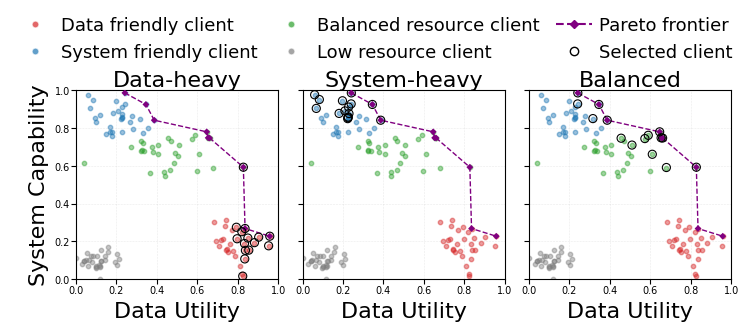

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_weighting_pareto_comparison(
    x_tick_fontsize=7,
    y_tick_fontsize=7,
    xlabel_fontsize=8,
    ylabel_fontsize=8,
    title_fontsize=8.5,
    legend_fontsize=7.5,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.02),
    fig_width=7.2,
    fig_height=3.1,
    wspace=0.12,
    hspace=0.0,
    n_clients=120,
    k=15,
    show_legend=True,
    random_seed=42,
):
    """
    Plot three weighting strategies against the Pareto frontier for FL client selection.

    Parameters
    ----------
    x_tick_fontsize : int or float
        Font size of x-axis tick labels.
    y_tick_fontsize : int or float
        Font size of y-axis tick labels.
    xlabel_fontsize : int or float
        Font size of x-axis labels.
    ylabel_fontsize : int or float
        Font size of y-axis labels.
    title_fontsize : int or float
        Font size of subplot titles.
    legend_fontsize : int or float
        Font size of legend text.
    legend_loc : str
        Legend location string for fig.legend().
    legend_bbox_to_anchor : tuple
        Legend anchor for fig.legend().
    fig_width : float
        Width of the whole figure.
    fig_height : float
        Height of the whole figure.
    wspace : float
        Width spacing between subplots.
    hspace : float
        Height spacing between subplots.
    n_clients : int
        Total number of simulated clients. Should be divisible by 4.
    k : int
        Number of top selected clients to highlight.
    show_legend : bool
        Whether to show the legend above the figure.
    random_seed : int
        Random seed for reproducibility.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes objects.
    """
    if n_clients % 4 != 0:
        raise ValueError("n_clients must be divisible by 4.")

    np.random.seed(random_seed)

    # ==========================================
    # 1. Simulate FL client data
    # ==========================================
    per_cluster = n_clients // 4

    c1 = np.random.multivariate_normal(
        [0.8, 0.2, 0.2],
        [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]],
        per_cluster
    )
    c2 = np.random.multivariate_normal(
        [0.2, 0.9, 0.8],
        [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]],
        per_cluster
    )
    c3 = np.random.multivariate_normal(
        [0.5, 0.5, 0.9],
        [[0.02, 0, 0], [0, 0.02, 0], [0, 0, 0.01]],
        per_cluster
    )
    c4 = np.random.multivariate_normal(
        [0.1, 0.1, 0.1],
        [[0.005, 0, 0], [0, 0.005, 0], [0, 0, 0.005]],
        per_cluster
    )

    X = np.vstack((c1, c2, c3, c4))
    X = np.clip(X, 0, 1)

    labels = np.array(
        ["C1"] * per_cluster +
        ["C2"] * per_cluster +
        ["C3"] * per_cluster +
        ["C4"] * per_cluster
    )

    cluster_colors = {
        "C1": "tab:red",
        "C2": "tab:blue",
        "C3": "tab:green",
        "C4": "tab:gray"
    }

    # ==========================================
    # 2. Build 2D axes for Pareto view
    # ==========================================
    data_utility = X[:, 0]
    system_capability = 0.6 * X[:, 1] + 0.4 * X[:, 2]
    points = np.column_stack((data_utility, system_capability))

    # ==========================================
    # 3. Pareto frontier computation
    # ==========================================
    def compute_pareto_frontier(pts: np.ndarray):
        is_pareto = np.ones(pts.shape[0], dtype=bool)
        for i in range(pts.shape[0]):
            for j in range(pts.shape[0]):
                if i != j:
                    if (
                        pts[j, 0] >= pts[i, 0]
                        and pts[j, 1] >= pts[i, 1]
                        and (pts[j, 0] > pts[i, 0] or pts[j, 1] > pts[i, 1])
                    ):
                        is_pareto[i] = False
                        break
        frontier = pts[is_pareto]
        frontier = frontier[np.argsort(frontier[:, 0])]
        return frontier, is_pareto

    pareto_points, pareto_mask = compute_pareto_frontier(points)

    # ==========================================
    # 4. Define three weighting strategies
    # ==========================================
    strategies = {
        "Data-heavy": np.array([0.85, 0.10, 0.05]),
        "System-heavy": np.array([0.10, 0.70, 0.20]),
        "Balanced": np.array([0.45, 0.35, 0.20]),
    }

    # ==========================================
    # 5. Plot
    # ==========================================
    fig, axes = plt.subplots(
        1, 3,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True
    )

    for ax, (title, weights) in zip(axes, strategies.items()):
        weights = weights / weights.sum()
        scores = X.dot(weights)
        top_idx = np.argsort(scores)[-k:]

        # scatter by cluster
        for cluster, color in cluster_colors.items():
            idx = labels == cluster
            ax.scatter(
                data_utility[idx],
                system_capability[idx],
                s=10,
                alpha=0.45,
                c=color
            )

        # pareto frontier
        ax.plot(
            pareto_points[:, 0],
            pareto_points[:, 1],
            linestyle="--",
            linewidth=1.0,
            color="purple"
        )
        ax.scatter(
            pareto_points[:, 0],
            pareto_points[:, 1],
            s=12,
            c="purple",
            marker="D",
            edgecolors="none",
            zorder=4
        )

        # selected clients
        ax.scatter(
            data_utility[top_idx],
            system_capability[top_idx],
            s=34,
            facecolors="none",
            edgecolors="black",
            linewidths=0.8,
            zorder=5
        )

        selected_pareto = np.sum(pareto_mask[top_idx])
        ax.text(
            0.03, 0.96,
            f"", #w=({weights[0]:.2f},{weights[1]:.2f},{weights[2]:.2f})\nP:{selected_pareto}/{k}
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=6.5,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.75", alpha=0.9)
        )

        ax.set_title(title, fontsize=title_fontsize, pad=2)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle="--", alpha=0.25, linewidth=0.4)
        ax.tick_params(axis="x", labelsize=x_tick_fontsize, pad=1)
        ax.tick_params(axis="y", labelsize=y_tick_fontsize, pad=1)

    axes[0].set_ylabel("System Capability", fontsize=ylabel_fontsize)
    for ax in axes:
        ax.set_xlabel("Data Utility", fontsize=xlabel_fontsize)

    if show_legend:
        legend_handles = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=5, alpha=0.7, label='Data friendly client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=5, alpha=0.7, label='System friendly client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=5, alpha=0.7, label='Balanced resource client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:gray', markersize=5, alpha=0.7, label='Low resource client'),
            Line2D([0], [0], marker='D', color='purple', linestyle='--', markersize=4, label='Pareto frontier'),
            Line2D([0], [0], marker='o', color='black', markerfacecolor='none', linestyle='None', markersize=6, label=f'Selected client')
        ]

        fig.legend(
            handles=legend_handles,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
            ncol=3,
            frameon=False,
            fontsize=legend_fontsize,
            handletextpad=0.4,
            columnspacing=0.9
        )

    plt.subplots_adjust(
        left=0.085,
        right=0.995,
        top=0.83 if show_legend else 0.93,
        bottom=0.22,
        wspace=wspace,
        hspace=hspace
    )

    return fig, axes


# =========================
# Example usage
# =========================
fig, axes = plot_weighting_pareto_comparison(
    x_tick_fontsize=7,
    y_tick_fontsize=7,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    title_fontsize=16,
    legend_fontsize=13,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.12),
    fig_width=7.2,
    fig_height=3.1,
    wspace=0.12,
    hspace=0.0,
)

plt.savefig("metric_weighting_problem.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_weighting_pareto_comparison(
    # ===== 统一字体控制 =====
    global_fontsize=None,

    # ===== 分项字体控制 =====
    x_tick_fontsize=7,
    y_tick_fontsize=7,
    xlabel_fontsize=8,
    ylabel_fontsize=8,
    title_fontsize=8.5,
    legend_fontsize=7.5,
    text_fontsize=6.5,

    # ===== legend 控制 =====
    show_legend=True,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.02),
    legend_ncol=3,

    # ===== 整体图尺寸控制 =====
    fig_width=7.2,
    fig_height=3.1,

    # ===== 子图间隙控制 =====
    wspace=0.12,
    hspace=0.0,

    # ===== 子图 xy 范围控制 =====
    xlim=(0, 1),
    ylim=(0, 1),

    # ===== 数据相关参数 =====
    n_clients=120,
    k=15,
    random_seed=42,
):
    """
    Plot three weighting strategies against the Pareto frontier for FL client selection.

    Parameters
    ----------
    global_fontsize : int or float or None
        If not None, override all font sizes with this value.

    x_tick_fontsize, y_tick_fontsize : int or float
        Tick label font sizes for x/y axes.
    xlabel_fontsize, ylabel_fontsize : int or float
        Axis label font sizes.
    title_fontsize : int or float
        Subplot title font size.
    legend_fontsize : int or float
        Legend font size.
    text_fontsize : int or float
        Internal annotation text font size.

    show_legend : bool
        Whether to show the legend.
    legend_loc : str
        Legend location for fig.legend().
    legend_bbox_to_anchor : tuple
        Anchor for fig.legend().
    legend_ncol : int
        Number of legend columns.

    fig_width, fig_height : float
        Figure width and height.

    wspace, hspace : float
        Subplot spacing.

    xlim, ylim : tuple
        Axis limits for all subplots.

    n_clients : int
        Total number of simulated clients. Must be divisible by 4.
    k : int
        Number of highlighted selected clients.
    random_seed : int
        Random seed.

    Returns
    -------
    fig, axes
        Matplotlib figure and axes objects.
    """
    if n_clients % 4 != 0:
        raise ValueError("n_clients must be divisible by 4.")

    # ===== 全局字体覆盖 =====
    if global_fontsize is not None:
        x_tick_fontsize = global_fontsize
        y_tick_fontsize = global_fontsize
        xlabel_fontsize = global_fontsize
        ylabel_fontsize = global_fontsize
        title_fontsize = global_fontsize
        legend_fontsize = global_fontsize
        text_fontsize = global_fontsize

    np.random.seed(random_seed)

    # ==========================================
    # 1. Simulate FL client data
    # ==========================================
    per_cluster = n_clients // 4

    c1 = np.random.multivariate_normal(
        [0.8, 0.2, 0.2],
        [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]],
        per_cluster
    )
    c2 = np.random.multivariate_normal(
        [0.2, 0.9, 0.8],
        [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01]],
        per_cluster
    )
    c3 = np.random.multivariate_normal(
        [0.5, 0.5, 0.9],
        [[0.02, 0, 0], [0, 0.02, 0], [0, 0, 0.01]],
        per_cluster
    )
    c4 = np.random.multivariate_normal(
        [0.1, 0.1, 0.1],
        [[0.005, 0, 0], [0, 0.005, 0], [0, 0, 0.005]],
        per_cluster
    )

    X = np.vstack((c1, c2, c3, c4))
    X = np.clip(X, 0, 1)

    labels = np.array(
        ["C1"] * per_cluster +
        ["C2"] * per_cluster +
        ["C3"] * per_cluster +
        ["C4"] * per_cluster
    )

    cluster_colors = {
        "C1": "tab:red",
        "C2": "tab:blue",
        "C3": "tab:green",
        "C4": "tab:gray"
    }

    # ==========================================
    # 2. Build 2D axes for Pareto view
    # ==========================================
    data_utility = X[:, 0]
    system_capability = 0.6 * X[:, 1] + 0.4 * X[:, 2]
    points = np.column_stack((data_utility, system_capability))

    # ==========================================
    # 3. Pareto frontier computation
    # ==========================================
    def compute_pareto_frontier(pts: np.ndarray):
        is_pareto = np.ones(pts.shape[0], dtype=bool)
        for i in range(pts.shape[0]):
            for j in range(pts.shape[0]):
                if i != j:
                    if (
                        pts[j, 0] >= pts[i, 0]
                        and pts[j, 1] >= pts[i, 1]
                        and (pts[j, 0] > pts[i, 0] or pts[j, 1] > pts[i, 1])
                    ):
                        is_pareto[i] = False
                        break
        frontier = pts[is_pareto]
        frontier = frontier[np.argsort(frontier[:, 0])]
        return frontier, is_pareto

    pareto_points, pareto_mask = compute_pareto_frontier(points)

    # ==========================================
    # 4. Define three weighting strategies
    # ==========================================
    strategies = {
        "Data-heavy": np.array([0.85, 0.10, 0.05]),
        "System-heavy": np.array([0.10, 0.70, 0.20]),
        "Balanced": np.array([0.45, 0.35, 0.20]),
    }

    # ==========================================
    # 5. Plot
    # ==========================================
    fig, axes = plt.subplots(
        1, 3,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True
    )

    for ax, (title, weights) in zip(axes, strategies.items()):
        weights = weights / weights.sum()
        scores = X.dot(weights)
        top_idx = np.argsort(scores)[-k:]

        # scatter by cluster
        for cluster, color in cluster_colors.items():
            idx = labels == cluster
            ax.scatter(
                data_utility[idx],
                system_capability[idx],
                s=10,
                alpha=0.45,
                c=color
            )

        # pareto frontier
        ax.plot(
            pareto_points[:, 0],
            pareto_points[:, 1],
            linestyle="--",
            linewidth=1.0,
            color="purple"
        )
        ax.scatter(
            pareto_points[:, 0],
            pareto_points[:, 1],
            s=12,
            c="purple",
            marker="D",
            edgecolors="none",
            zorder=4
        )

        # selected clients
        ax.scatter(
            data_utility[top_idx],
            system_capability[top_idx],
            s=34,
            facecolors="none",
            edgecolors="black",
            linewidths=0.8,
            zorder=5
        )

        selected_pareto = np.sum(pareto_mask[top_idx])
        ax.text(
            0.03, 0.96,
            f"P:{selected_pareto}/{k}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=text_fontsize,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.75", alpha=0.9)，
        )

        ax.set_title(title, fontsize=title_fontsize, pad=2)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.grid(True, linestyle="--", alpha=0.25, linewidth=0.4)
        ax.tick_params(axis="x", labelsize=x_tick_fontsize, pad=1)
        ax.tick_params(axis="y", labelsize=y_tick_fontsize, pad=1)

    axes[0].set_ylabel("System Capability", fontsize=ylabel_fontsize)
    for ax in axes:
        ax.set_xlabel("Data Utility", fontsize=xlabel_fontsize)

    if show_legend:
        legend_handles = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',
                   markersize=5, alpha=0.7, label='Data friendly client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',
                   markersize=5, alpha=0.7, label='System friendly client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green',
                   markersize=5, alpha=0.7, label='Balanced resource client'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:gray',
                   markersize=5, alpha=0.7, label='Low resource client'),
            Line2D([0], [0], marker='D', color='purple', linestyle='--',
                   markersize=4, label='Pareto frontier'),
            Line2D([0], [0], marker='o', color='black', markerfacecolor='none',
                   linestyle='None', markersize=6, label='Selected client')
        ]

        fig.legend(
            handles=legend_handles,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
            ncol=legend_ncol,
            frameon=False,
            fontsize=legend_fontsize,
            handletextpad=0.4,
            columnspacing=0.9
        )

    plt.subplots_adjust(
        left=0.085,
        right=0.995,
        top=0.83 if show_legend else 0.93,
        bottom=0.22,
        wspace=wspace,
        hspace=hspace
    )

    return fig, axes


# =========================
# Example usage
# =========================
fig, axes = plot_weighting_pareto_comparison(
    global_fontsize=None,      # 设成 12 / 14 可统一控制所有字体
    x_tick_fontsize=7,
    y_tick_fontsize=7,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    title_fontsize=16,
    legend_fontsize=13,
    text_fontsize=10,
    legend_loc="upper center",
    legend_bbox_to_anchor=(0.5, 1.12),
    legend_ncol=3,
    fig_width=7.2,
    fig_height=3.1,
    wspace=0.12,
    hspace=0.0,
    xlim=(0, 1),
    ylim=(0, 1),
)

plt.savefig("metric_weighting_problem.pdf", dpi=600, bbox_inches="tight")
plt.show()

SyntaxError: invalid character '，' (U+FF0C) (1033849588.py, line 249)

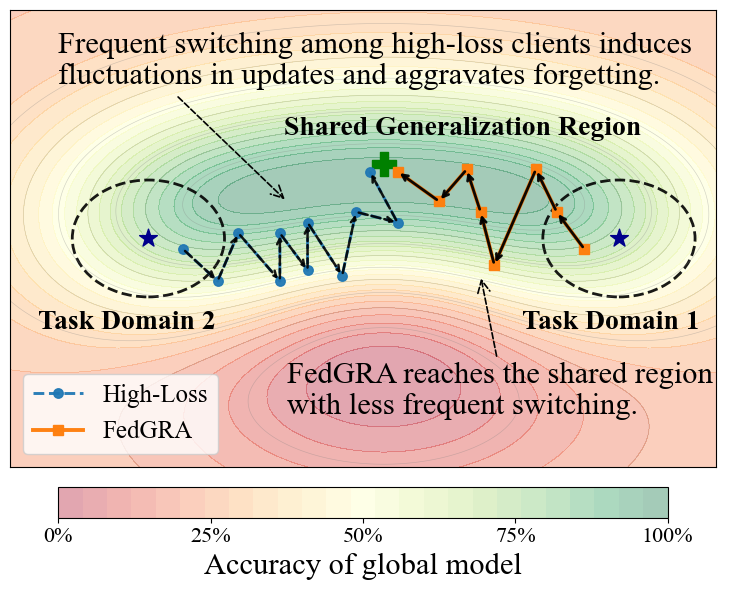

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

def plot_joint_generalization_process(
    figsize=(8.4, 6.6),

    # -----------------------------
    # Font size controls
    # -----------------------------
    title_fontsize=14,
    xlabel_fontsize=11,
    ylabel_fontsize=11,
    xtick_fontsize=10,
    ytick_fontsize=10,
    cbar_label_fontsize=10,
    cbar_tick_fontsize=9,
    legend_fontsize=10,
    domain_label_fontsize=11,
    annotation_fontsize=10,   # 3. annotation字体大小接口

    # -----------------------------
    # Line / marker / style controls
    # -----------------------------
    highloss_linewidth=2.1,
    fedgra_linewidth=2.8,
    highloss_markersize=6.8,
    fedgra_markersize=6.5,
    domain_circle_radius=0.55,

    # -----------------------------
    # Joint marker ("绿色叉/十字/plus") controls
    # -----------------------------
    joint_marker='P',
    joint_marker_size=180,    # 2. 中间绿色叉大小接口
    joint_marker_color='green',

    # -----------------------------
    # Task-domain star controls
    # -----------------------------
    d1=(1.6, 0.6),            # 4. domain 1 星星位置接口
    d2=(-1.6, 0.6),           # 4. domain 2 星星位置接口
    domain_star_color='black',# 4. 两个task domain星星颜色接口
    domain_star_size=130,     # 4. 两个task domain星星大小接口
    joint=(0.0, 1.25),        # 2. 中间绿色叉位置接口（如果你也想调位置）

    save_path=None,
    path_a=np.array([
        [1.45, 0.55],
        [0.65, 0.10],
        [-1.05, 1.05],
        [0.55, 0.25],
        [-0.75, 1.18],
        [0.25, 0.58],
        [-0.20, 1.02],
        [0.12, 0.86],
    ]),
    path_b=np.array([
        [1.45, 0.55],
        [1.00, 0.95],
        [0.42, 0.82],
        [0.58, 1.16],
        [0.12, 1.05],
        [0.00, 1.28],
    ]),
    dpi=300
):
    # -----------------------------
    # Global font
    # -----------------------------
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['mathtext.fontset'] = 'stix'

    # -----------------------------
    # 1. Construct toy landscape
    # -----------------------------
    x = np.linspace(-3, 3, 300)
    y = np.linspace(-3, 3, 300)
    X, Y = np.meshgrid(x, y)

    domain1 = np.exp(-((X - 1.4) ** 2 / 1.2 + (Y - 0.8) ** 2 / 1.0))
    domain2 = np.exp(-((X + 1.4) ** 2 / 1.2 + (Y - 0.8) ** 2 / 1.0))
    shared = 1.25 * np.exp(-((X) ** 2 / 1.8 + (Y - 1.2) ** 2 / 0.9))
    unstable = 0.55 * np.exp(-((X) ** 2 / 2.5 + (Y + 0.3) ** 2 / 1.8))

    Z_raw = domain1 + domain2 + shared - unstable
    Z = (Z_raw - Z_raw.min()) / (Z_raw.max() - Z_raw.min())

    fig, ax = plt.subplots(figsize=figsize)

    contour = ax.contourf(X, Y, Z, levels=24, cmap='RdYlGn', alpha=0.36)
    ax.contour(X, Y, Z, levels=10, colors='gray', linewidths=0.45, alpha=0.35)

    # -----------------------------
    # 1. 顶部横向 colorbar
    # -----------------------------
    cbar = plt.colorbar(
        contour,
        ax=ax,
        orientation='horizontal',  # 放到上面
        location='bottom',
        shrink=1,
        fraction=0.06,
        pad=0.04
    )
    cbar.set_label("Accuracy of global model", fontsize=cbar_label_fontsize)
    cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_ticklabels(["0%", "25%", "50%", "75%", "100%"])
    cbar.ax.tick_params(labelsize=cbar_tick_fontsize)
    cbar.ax.xaxis.set_ticks_position('bottom')

    # -----------------------------
    # 2. Domain anchors
    # -----------------------------
    ax.scatter(*d1, s=domain_star_size, marker='*', color=domain_star_color, zorder=6)
    ax.scatter(*d2, s=domain_star_size, marker='*', color=domain_star_color, zorder=6)
    ax.scatter(*joint, s=joint_marker_size, marker=joint_marker, color=joint_marker_color, zorder=7)

    circle1 = Circle(
        d1,
        radius=domain_circle_radius,
        fill=False,
        linewidth=2.0,
        linestyle='--',
        alpha=0.9
    )
    circle2 = Circle(
        d2,
        radius=domain_circle_radius,
        fill=False,
        linewidth=2.0,
        linestyle='--',
        alpha=0.9
    )
    ax.add_patch(circle1)
    ax.add_patch(circle2)

    ax.text(
        d1[0] - 0.7, d1[1] - 0.85, "Task Domain 1",
        fontsize=domain_label_fontsize,
        fontweight='bold'
    )
    ax.text(
        d2[0] - 0.8, d2[1] - 0.85, "Task Domain 2",
        fontsize=domain_label_fontsize,
        fontweight='bold'
    )
    ax.text(
        joint[0] - 0.72, joint[1] + 0.27, "Shared Generalization Region",
        fontsize=domain_label_fontsize,
        fontweight='bold'
    )

    # -----------------------------
    # 3. High-loss path
    # -----------------------------
    ax.plot(
        path_a[:, 0], path_a[:, 1],
        '--o',
        lw=highloss_linewidth,
        markersize=highloss_markersize,
        alpha=0.94,
        label='High-Loss',
        zorder=8
    )

    for i in range(len(path_a) - 1):
        ax.annotate(
            "",
            xy=path_a[i + 1],
            xytext=path_a[i],
            arrowprops=dict(
                arrowstyle="->",
                lw=1.8,
                linestyle='--',
                shrinkA=2,
                shrinkB=2,
                alpha=0.9
            ),
            zorder=9
        )

    # -----------------------------
    # 4. FedGRA path
    # -----------------------------
    ax.plot(
        path_b[:, 0], path_b[:, 1],
        '-s',
        lw=fedgra_linewidth,
        markersize=fedgra_markersize,
        alpha=0.98,
        label='FedGRA',
        zorder=10
    )

    for i in range(len(path_b) - 1):
        ax.annotate(
            "",
            xy=path_b[i + 1],
            xytext=path_b[i],
            arrowprops=dict(
                arrowstyle="->",
                lw=2.0,
                shrinkA=2,
                shrinkB=2,
                alpha=0.95
            ),
            zorder=11
        )

    # -----------------------------
    # 5. Annotations
    # -----------------------------
    ax.annotate(
        "Frequent switching among high-loss clients induces \nfluctuations in updates and aggravates forgetting.",
        xy=(-0.7, 1),
        xytext=(-2.35, 2.10),
        fontsize=annotation_fontsize,
        ha='left',
    )

    ax.annotate(
        "",
        xy=(-0.7, 1),
        xytext=(-1.5, 2),
        fontsize=annotation_fontsize,
        ha='left',
        arrowprops=dict(
            arrowstyle='->',
            lw=1.2,
            linestyle='--'
        )
    )

    ax.annotate(
        "FedGRA reaches the shared region \nwith less frequent switching.",
        xy=(0.7, 0.3),
        xytext=(-0.7, -1),
        fontsize=annotation_fontsize,
        ha='left',
        arrowprops=dict(
            arrowstyle='->',
            lw=1.2,
            linestyle='--'
        )
    )

    # -----------------------------
    # 6. Axes / legend
    # -----------------------------
    # ax.set_title("Illustration of Joint Generalization", fontsize=title_fontsize)
    # ax.set_xlabel("Preference Toward Domain 1", fontsize=xlabel_fontsize)
    # ax.set_ylabel("Preference Toward Domain 2", fontsize=ylabel_fontsize)
    ax.tick_params(axis='x', labelsize=xtick_fontsize, labelcolor='white')
    ax.tick_params(axis='y', labelsize=ytick_fontsize, labelcolor='white')

    ax.legend(fontsize=legend_fontsize, loc='lower left', frameon=True)
    ax.grid(alpha=0.18, linestyle='--')
    ax.set_ylim(-1.5, 2.8)
    ax.set_xlim(-2.7, 2.4)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

plot_joint_generalization_process(

    figsize=(8, 6),
    title_fontsize=16,
    xlabel_fontsize=13,
    ylabel_fontsize=13,
    xtick_fontsize=11,
    ytick_fontsize=11,
    cbar_label_fontsize=22,
    cbar_tick_fontsize=16,
    legend_fontsize=18,
    domain_label_fontsize=20,
    annotation_fontsize=22,
    save_path="high_loss_problem_illustration.pdf",
    path_a=np.array([
        [-1.45, 0.55],
        [-1.2, 0.25],
        [-1.05, 0.7],
        [-0.75, 0.25],
        [-0.75, 0.7],
        [-0.55, 0.35],
        [-0.55, 0.8],
        [-0.3, 0.3],
        [-0.2, 0.9],
        [0.1, 0.8],
        [-0.1, 1.28],
    ]),
    path_b=np.array([
        [1.45, 0.55],
        [1.25, 0.9],
        [1.1, 1.3],
        [0.8, 0.4],
        [0.7, 0.9],
        [0.6, 1.3],
        [0.4, 1.0],
        [0.1, 1.28],
    ]),
    joint_marker_size=300,
    joint_marker_color='green',
    joint=(0.0, 1.35),

    d1=(1.7, 0.65),
    d2=(-1.7, 0.65),
    domain_star_color='darkblue',
    domain_star_size=180,
)

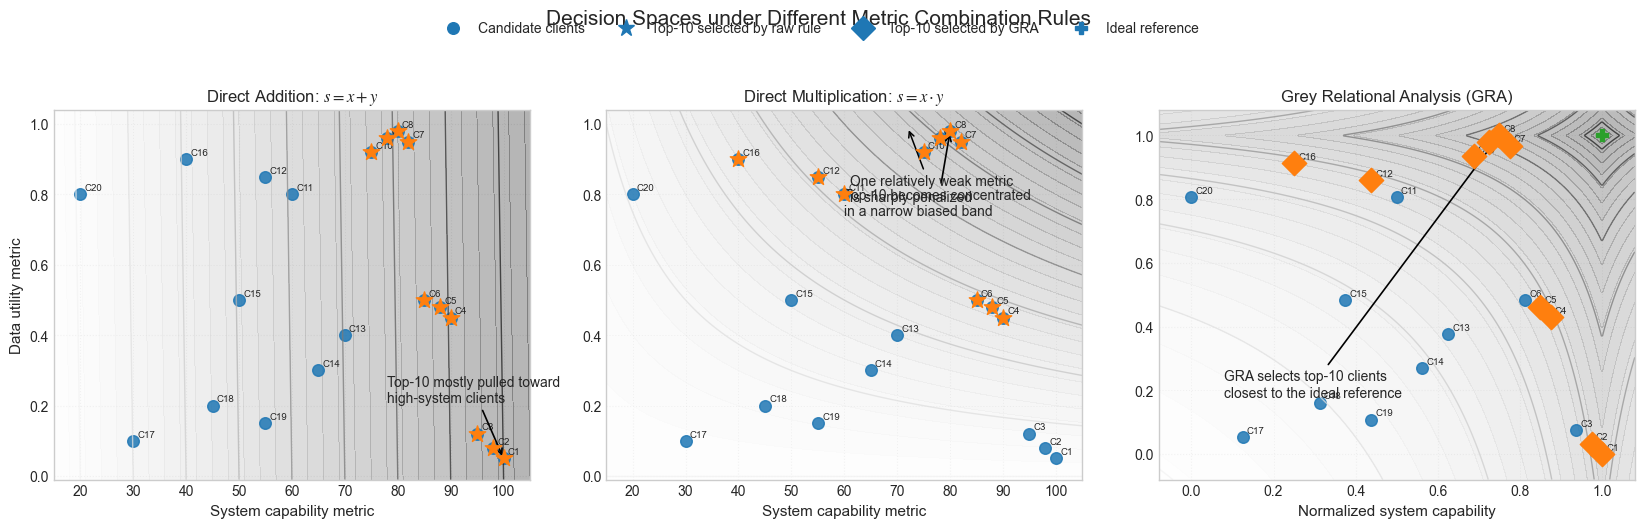

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_three_decision_spaces_topk(
    figsize=(17, 5.6),
    point_size=70,
    selected_point_scale=2.2,
    top_k=4,

    # title / fonts
    title="Decision Spaces under Different Metric Combination Rules",
    title_fontsize=15,
    subplot_title_fontsize=12,
    label_fontsize=11,
    tick_fontsize=10,
    annotation_fontsize=10,
    legend_fontsize=10,
    client_label_fontsize=7,

    # layout
    wspace=0.16,
    top=0.80,
    left=0.05,
    right=0.98,
    bottom=0.14,

    # legend
    show_legend=True,
    legend_loc="upper center",
    legend_ncol=4,
    legend_bbox_to_anchor=(0.5, 0.98),

    # contour / background
    contour_levels=10,
    contourf_levels=30,
    contour_alpha=0.30,
    contour_line_alpha=0.75,
    grid_alpha=0.30,

    # client labels / annotations
    show_client_labels=True,
    show_annotations=True,
    client_label_dx=3,
    client_label_dy=3,

    # axis padding
    x_pad=5,
    y_pad=0.06,
    norm_pad=0.08,

    # GRA
    gra_rho=0.5,

    # style
    show_grid=True,

    # save
    save_path=None,
    dpi=300
):
    """
    3 subplots:
      1) direct addition      s = x + y
      2) direct multiplication s = x * y
      3) GRA-based selection   grey relational grade

    Design goal:
      - Many clients
      - Top-k selection
      - Multiplication becomes visibly biased under imbalanced metrics
    """

    # -------------------------------------------------
    # Synthetic client design
    #
    # x: system capability (large scale)
    # y: data utility      (small scale)
    #
    # Group A: system-heavy, high x but weak/moderate y
    # Group B: balanced, strong in both
    # Group C: data-valuable, moderate x but very high y
    #
    # Desired behavior:
    # - addition: heavily pulled by x
    # - multiplication: strongly favors a narrow band with both metrics non-low,
    #   while sharply suppressing clients with one relatively weak metric
    # - GRA: prefers clients close to the ideal point
    # -------------------------------------------------
    clients = {
        "C1":  (100, 0.05), 
        "C2":  (98,  0.08),
        "C3":  (95,  0.12),

        # --- Group B: 系统指标高且数据中等 (诱导乘法规则失效) ---
        # 这些点的 x*y 会很大，但在归一化空间里，y 轴的亏损比 x 轴的增益严重
        "C4":  (90,  0.45),
        "C5":  (88,  0.48),
        "C6":  (85,  0.50),

        # --- Group C: 真正均衡的 Client (GRA 应该选出的结果) ---
        # 它们的系统指标虽然不是顶尖(70-80)，但数据质量非常好(0.9+)
        # 在归一化空间中，它们最接近 (1.0, 1.0)
        "C7":  (82,  0.95), # <--- GRA 理想目标
        "C8":  (80,  0.98), # <--- GRA 理想目标
        "C9":  (78,  0.96), # <--- GRA 理想目标
        "C10": (75,  0.92), # <--- GRA 理想目标

        # --- Group D: 边缘/填充点 ---
        "C11": (60,  0.80),
        "C12": (55,  0.85),
        "C13": (70,  0.40),
        "C14": (65,  0.30),
        "C15": (50,  0.50),
        "C16": (40,  0.90),
        "C17": (30,  0.10),
        "C18": (45,  0.20),
        "C19": (55,  0.15),
        "C20": (20,  0.80),
    }

    names = list(clients.keys())
    x = np.array([clients[k][0] for k in names], dtype=float)
    y = np.array([clients[k][1] for k in names], dtype=float)

    # -------------------------------------------------
    # Normalization
    # -------------------------------------------------
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # -------------------------------------------------
    # Scores
    # -------------------------------------------------
    score_add = x + y
    score_mul = x * y

    # GRA
    # GRA / EWM
    gra_rho=0.5,
    use_ewm_for_gra=True,
    ewm_eps=1e-12,
    ref = np.array([1.0, 1.0])
    data_norm = np.column_stack([x_norm, y_norm])
    delta = np.abs(data_norm - ref)

    delta_min = delta.min()
    delta_max = delta.max()

    gra_coeff = (delta_min + gra_rho * delta_max) / (delta + gra_rho * delta_max)

    # -------------------------------------------------
    # EWM weights for GRA metrics
    # -------------------------------------------------
    if use_ewm_for_gra:
        # p_ij: proportion of client i on metric j
        p = data_norm / (data_norm.sum(axis=0, keepdims=True) + ewm_eps)

        n = data_norm.shape[0]
        k = 1.0 / np.log(n)

        # entropy of each metric
        entropy = -k * np.sum(p * np.log(p + ewm_eps), axis=0)

        # degree of diversification
        d = 1.0 - entropy

        # normalized weights
        ewm_weights = d / (d.sum() + ewm_eps)
    else:
        ewm_weights = np.ones(data_norm.shape[1]) / data_norm.shape[1]

    # weighted grey relational grade
    gra_grade = np.sum(gra_coeff * ewm_weights, axis=1)
    # -------------------------------------------------
    # Top-k selection indices
    # -------------------------------------------------
    top_add = np.argsort(score_add)[-top_k:][::-1]
    top_mul = np.argsort(score_mul)[-top_k:][::-1]
    top_gra = np.argsort(gra_grade)[-top_k:][::-1]

    # -------------------------------------------------
    # Meshgrid for decision-space visualization
    # -------------------------------------------------
    x_min, x_max = x.min() - x_pad, x.max() + x_pad
    y_min, y_max = y.min() - y_pad, y.max() + y_pad

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    zz_add = xx + yy
    zz_mul = xx * yy

    # normalized space for GRA subplot
    xn_min, xn_max = 0 - norm_pad, 1 + norm_pad
    yn_min, yn_max = 0 - norm_pad, 1 + norm_pad

    xxn, yyn = np.meshgrid(
        np.linspace(xn_min, xn_max, 400),
        np.linspace(yn_min, yn_max, 400)
    )

    delta_grid_x = np.abs(xxn - 1.0)
    delta_grid_y = np.abs(yyn - 1.0)
    delta_grid = np.stack([delta_grid_x, delta_grid_y], axis=-1)

    gra_coeff_grid = (delta_min + gra_rho * delta_max) / (delta_grid + gra_rho * delta_max)
    zz_gra = gra_coeff_grid.mean(axis=-1)

    # -------------------------------------------------
    # Figure
    # -------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle(title, fontsize=title_fontsize)

    # =================================================
    # Subplot 1: Direct Addition
    # =================================================
    ax = axes[0]
    ax.contourf(xx, yy, zz_add, levels=contourf_levels, alpha=contour_alpha)
    ax.contour(xx, yy, zz_add, levels=contour_levels, linewidths=1.0, alpha=contour_line_alpha)

    ax.scatter(x, y, s=point_size, alpha=0.85)
    ax.scatter(
        x[top_add], y[top_add],
        s=point_size * selected_point_scale,
        marker='*',
        zorder=5
    )

    if show_client_labels:
        for i, name in enumerate(names):
            ax.annotate(
                name, (x[i], y[i]),
                xytext=(client_label_dx, client_label_dy),
                textcoords="offset points",
                fontsize=client_label_fontsize
            )

    if show_annotations:
        ax.annotate(
            f"Top-{top_k} mostly pulled toward\nhigh-system clients",
            xy=(x[top_add[0]], y[top_add[0]]),
            xytext=(x[top_add[0]] - 22, y[top_add[0]] + 0.16),
            arrowprops=dict(arrowstyle='->', lw=1.2),
            fontsize=annotation_fontsize
        )

    ax.set_title("Direct Addition: $s=x+y$", fontsize=subplot_title_fontsize)
    ax.set_xlabel("System capability metric", fontsize=label_fontsize)
    ax.set_ylabel("Data utility metric", fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if show_grid:
        ax.grid(True, linestyle=':', alpha=grid_alpha)

    # =================================================
    # Subplot 2: Direct Multiplication
    # =================================================
    ax = axes[1]
    ax.contourf(xx, yy, zz_mul, levels=contourf_levels, alpha=contour_alpha)
    ax.contour(xx, yy, zz_mul, levels=contour_levels, linewidths=1.0, alpha=contour_line_alpha)

    ax.scatter(x, y, s=point_size, alpha=0.85)
    ax.scatter(
        x[top_mul], y[top_mul],
        s=point_size * selected_point_scale,
        marker='*',
        zorder=5
    )

    if show_client_labels:
        for i, name in enumerate(names):
            ax.annotate(
                name, (x[i], y[i]),
                xytext=(client_label_dx, client_label_dy),
                textcoords="offset points",
                fontsize=client_label_fontsize
            )

    if show_annotations:
        ax.annotate(
            f"Top-{top_k} becomes concentrated\nin a narrow biased band",
            xy=(x[top_mul[0]], y[top_mul[0]]),
            xytext=(x[top_mul[0]] - 20, y[top_mul[0]] - 0.24),
            arrowprops=dict(arrowstyle='->', lw=1.2),
            fontsize=annotation_fontsize
        )
        ax.annotate(
            "One relatively weak metric\nis sharply penalized",
            xy=(72, 0.99),
            xytext=(61, 0.78),
            arrowprops=dict(arrowstyle='->', lw=1.1),
            fontsize=annotation_fontsize
        )

    ax.set_title("Direct Multiplication: $s=x\\cdot y$", fontsize=subplot_title_fontsize)
    ax.set_xlabel("System capability metric", fontsize=label_fontsize)
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    if show_grid:
        ax.grid(True, linestyle=':', alpha=grid_alpha)

    # =================================================
    # Subplot 3: GRA
    # =================================================
    ax = axes[2]
    ax.contourf(xxn, yyn, zz_gra, levels=contourf_levels, alpha=contour_alpha)
    ax.contour(xxn, yyn, zz_gra, levels=contour_levels, linewidths=1.0, alpha=contour_line_alpha)

    ax.scatter(x_norm, y_norm, s=point_size, alpha=0.85)
    ax.scatter(
        x_norm[top_gra], y_norm[top_gra],
        s=point_size * selected_point_scale,
        marker='D',
        zorder=5
    )

    # ideal reference
    ax.scatter([1.0], [1.0], s=point_size * 1.2, marker='P', zorder=5)

    if show_client_labels:
        for i, name in enumerate(names):
            ax.annotate(
                name, (x_norm[i], y_norm[i]),
                xytext=(client_label_dx, client_label_dy),
                textcoords="offset points",
                fontsize=client_label_fontsize
            )

    if show_annotations:
        ax.annotate(
            f"GRA selects top-{top_k} clients\nclosest to the ideal reference",
            xy=(x_norm[top_gra[0]], y_norm[top_gra[0]]),
            xytext=(0.08, 0.18),
            arrowprops=dict(arrowstyle='->', lw=1.2),
            fontsize=annotation_fontsize
        )

    ax.set_title("Grey Relational Analysis (GRA)", fontsize=subplot_title_fontsize)
    ax.set_xlabel("Normalized system capability", fontsize=label_fontsize)
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    ax.set_xlim(xn_min, xn_max)
    ax.set_ylim(yn_min, yn_max)
    if show_grid:
        ax.grid(True, linestyle=':', alpha=grid_alpha)

    # -------------------------------------------------
    # Shared legend
    # -------------------------------------------------
    if show_legend:
        legend_handles = [
            Line2D(
                [0], [0], marker='o', linestyle='None',
                markersize=np.sqrt(point_size),
                label='Candidate clients'
            ),
            Line2D(
                [0], [0], marker='*', linestyle='None',
                markersize=np.sqrt(point_size * selected_point_scale),
                label=f'Top-{top_k} selected by raw rule'
            ),
            Line2D(
                [0], [0], marker='D', linestyle='None',
                markersize=np.sqrt(point_size * selected_point_scale * 0.9),
                label=f'Top-{top_k} selected by GRA'
            ),
            Line2D(
                [0], [0], marker='P', linestyle='None',
                markersize=np.sqrt(point_size * 1.1),
                label='Ideal reference'
            ),
        ]

        fig.legend(
            handles=legend_handles,
            loc=legend_loc,
            ncol=legend_ncol,
            bbox_to_anchor=legend_bbox_to_anchor,
            fontsize=legend_fontsize,
            frameon=False
        )

    fig.subplots_adjust(
        left=left, right=right, bottom=bottom, top=top, wspace=wspace
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


# Example usage
plot_three_decision_spaces_topk(top_k=10)